# Figure S14: Comparisons of all model-based parameters between intact and dStr-lesioned rats

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

Found 84 rats in the DATA folder
Listed 57 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 15 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [3]:
sequence = {}
for index, animal in enumerate(all_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal, session, name="sequence.p")

In [4]:
# load the model fits
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

conds = ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20']
vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u]
names = ['alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']

# S14A difference intact vs. lesion for α0, αt, αu, γ0, γt and γu across the 8 action costs 
# S14B Same as S14A, for μ0, μt, μu, σ0, σt and σu

[0.9671 0.9906 0.996  1.     0.9997 0.9997 0.9989 1.    ]


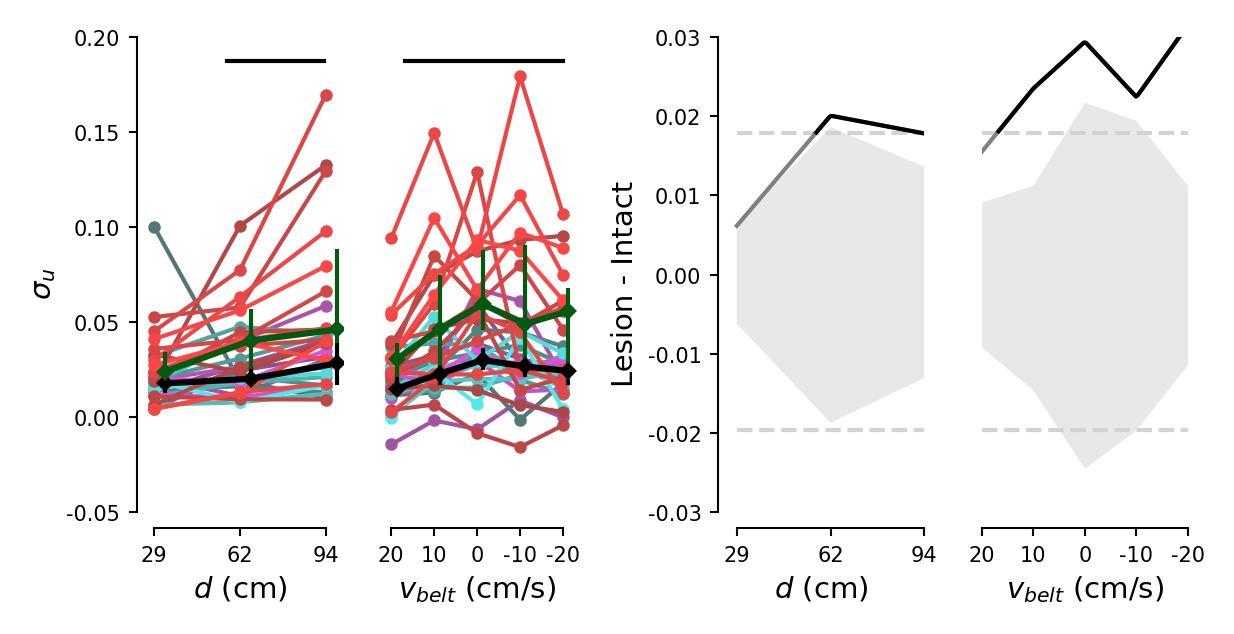

In [ ]:
def FigureS14AB(var, name='', plot_params=GENERAL_PLOT_PARAMS, intact_rats=intact_rats, VSlesioned_rats=VSlesioned_rats, ax_d=None, ax_vbelt=None, ax_stat_d=None, ax_stat_vbelt=None):
    if ax_d is None or ax_stat_d is None:
        fig, (ax_d, ax_vbelt, ax_stat_d, ax_stat_vbelt) = plt.subplots(1, 4, figsize=(4, 2))
    conds = ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20']
    intact = []
    lesion = []
    for animal in intact_rats:
        ax_d.plot([0, 1, 2], [var[animal][cond] for cond in ['60', '90', '120']], color=rat_markers[animal][0],
                marker=rat_markers[animal][1], ms=2)
        ax_vbelt.plot([0, 1, 2, 3, 4], [var[animal][cond] for cond in ['20', '10', '2', 'rev10', 'rev20']], color=rat_markers[animal][0],
                marker=rat_markers[animal][1], ms=2)
        intact.append([var[animal][cond] for cond in conds])
    for animal in VSlesioned_rats:
        ax_d.plot([0, 1, 2], [var[animal][cond] for cond in ['60', '90', '120']], color=rat_markers[animal][0],
                marker=rat_markers[animal][1], ms=2)
        ax_vbelt.plot([0, 1, 2, 3, 4], [var[animal][cond] for cond in ['20', '10', '2', 'rev10', 'rev20']], color=rat_markers[animal][0],
                marker=rat_markers[animal][1], ms=2)
        lesion.append([var[animal][cond] for cond in conds])

    ngroup1 = len(intact)
    num_permutations = 10000

    median_intact = np.median(intact, axis=0)
    median_lesion = np.median(lesion, axis=0)

    _ = r'$d$'
    ax_d.set_xlabel(f'{_} (cm)')
    ax_d.set_ylabel(plot_params[name]['ylabel'])
    ax_d.set_xlim(0, 2)
    ax_d.set_ylim(plot_params[name]['yticks'][0], plot_params[name]['yticks'][-1])
    ax_d.set_yticks(plot_params[name]['yticks'])
    ax_d.set_xticks(np.arange(3))
    ax_d.set_xticklabels(["29", "62", "94"])
    space_axes(ax_d, x_ratio_left=.1, x_ratio_right=.1)

    _ = r'$v_{\mathrm{belt}}$'
    ax_vbelt.set_xlabel(f'{_} (cm/s)')
    ax_vbelt.set_xlim(0, 4)
    ax_vbelt.set_ylim(plot_params[name]['yticks'][0], plot_params[name]['yticks'][-1])
    ax_vbelt.set_yticks(plot_params[name]['yticks'])
    ax_vbelt.set_xticks(np.arange(5))
    ax_vbelt.set_xticklabels(["20", "10", "0", "-10", "-20"]) #±2
    ax_vbelt.spines['left'].set_visible(False)
    ax_vbelt.tick_params(left=False, labelleft=False)
    space_axes(ax_vbelt, x_ratio_left=.1, x_ratio_right=.1)

    observed_diff = median_lesion - median_intact
    permuted_diffs = np.zeros((num_permutations, 8))

    for i in range(num_permutations):
        combined_data = np.concatenate([intact, lesion], axis=0)
        np.random.shuffle(combined_data)

        permuted_diff = np.median(combined_data[:ngroup1], axis=0) - np.median(combined_data[ngroup1:], axis=0)
        permuted_diffs[i] = permuted_diff

    p_values = np.mean(permuted_diffs <= observed_diff, axis=0)

    print(p_values)

    plotmedian(var, ax=ax_d, dist_or_tm='dist', animal_list=intact_rats, err='percentile', color='k')
    plotmedian(var, ax=ax_d, dist_or_tm='dist', animal_list=VSlesioned_rats, err='percentile', color='xkcd:deep green')
    plotmedian(var, ax=ax_vbelt, dist_or_tm='tm', animal_list=intact_rats, err='percentile', color='k', shift_tm=False)
    plotmedian(var, ax=ax_vbelt, dist_or_tm='tm', animal_list=VSlesioned_rats, err='percentile', color='xkcd:deep green', shift_tm=False)

    alpha = 100 # Global alpha value
    highGlobCI = 2.5
    lowGlobCI = 2.5
    while alpha >= 5:
        highBand = np.percentile(a=permuted_diffs, q=100-highGlobCI)
        lowBand = np.percentile(a=permuted_diffs, q=lowGlobCI)

        breaksPositive = np.sum([np.sum(permuted_diffs[i, :] > highBand) > 1 for i in range(len(permuted_diffs))])
        breaksNegative = np.sum([np.sum(permuted_diffs[i, :] < lowBand) > 1 for i in range(len(permuted_diffs))])
        
        alpha = ((breaksPositive + breaksNegative) / len(permuted_diffs)) * 100
        highGlobCI = 0.95 * highGlobCI
        lowGlobCI = 0.95 * lowGlobCI
    
    for ax_stat in [ax_stat_d, ax_stat_vbelt]:
        ax_stat.plot(range(8), [lowBand for _ in range(8)], color='lightgray', ls='--', label='Global 95% CI band')
        ax_stat.plot(range(8), [highBand for _ in range(8)], color='lightgray', ls='--', label='Global 95% CI band')

    ######################################
    CI = np.percentile(permuted_diffs[:, :], [2.5, 97.5], axis=0)
    y = np.concatenate([CI[0][0:3], CI[1][0:3][::-1]])
    x = np.concatenate([[0, 1, 2], [2, 1, 0]])
    ax_stat_d.fill(x, y, alpha=.5, color='lightgray', label='95% CI', zorder=0, lw=0)

    y = np.concatenate([CI[0][3:8], CI[1][3:8][::-1]])
    x = np.concatenate([[0, 1, 2, 3, 4], [4, 3, 2, 1, 0]])
    ax_stat_vbelt.fill(x, y, alpha=.5, color='lightgray', label='95% CI', zorder=0, lw=0)

    shift = np.sqrt(np.sum((plot_params[name]['yticks'][0] - plot_params[name]['yticks'][-1]) ** 2, axis=0)) * 0.95 + plot_params[name]['yticks'][0]
    for x, y, ax, ax_stat in zip([[0, 1, 2], [0, 1, 2, 3, 4]], [observed_diff[0:3], observed_diff[3:8]], [ax_d, ax_vbelt], [ax_stat_d, ax_stat_vbelt]):
        f = interp1d(x, y, kind='linear')
        xnew = np.linspace(x[0], x[-1], num=100, endpoint=True)
        ynew = f(xnew)
        # plot y above highBand
        mask_above = ynew > highBand
        if np.any(mask_above):
            idx = np.where(mask_above)[0]
            # Find contiguous segments
            splits = np.split(idx, np.where(np.diff(idx) != 1)[0]+1)
            for seg in splits:
                if len(seg) > 0:
                    ax.plot(xnew[seg], np.full_like(xnew[seg], shift), color='k', zorder=10, label='Significant difference' if seg is splits[0] else None)
                    ax_stat.plot(xnew[seg], ynew[seg], color='k', zorder=10, label='Significant difference' if seg is splits[0] else None)
        # plot y below lowBand
        mask_below = ynew < lowBand
        if np.any(mask_below):
            idx = np.where(mask_below)[0]
            splits = np.split(idx, np.where(np.diff(idx) != 1)[0]+1)
            for seg in splits:
                if len(seg) > 0:
                    ax.plot(xnew[seg], np.full_like(xnew[seg], shift), color='k', zorder=10)
                    ax_stat.plot(xnew[seg], ynew[seg], color='k', zorder=10)
        # non significant regions
        ax_stat.plot(xnew, ynew, color='gray', zorder=8)

    _ = r'$d$'
    ax_stat_d.set_xlabel(f'{_} (cm)')
    ax_stat_d.set_ylabel('Lesion - Intact')
    ax_stat_d.set_xlim(0, 2)
    ax_stat_d.set_ylim(plot_params[name]['yticksdiff'][0], plot_params[name]['yticksdiff'][-1])
    ax_stat_d.set_yticks(plot_params[name]['yticksdiff'])
    ax_stat_d.set_xticks(np.arange(3))
    ax_stat_d.set_xticklabels(["29", "62", "94"])
    space_axes(ax_stat_d, x_ratio_left=.1, x_ratio_right=0)

    _ = r'$v_{\mathrm{belt}}$'
    ax_stat_vbelt.set_xlabel(f'{_} (cm/s)')
    ax_stat_vbelt.set_xlim(0, 4)
    ax_stat_vbelt.set_ylim(plot_params[name]['yticksdiff'][0], plot_params[name]['yticksdiff'][-1])
    ax_stat_vbelt.set_yticks(plot_params[name]['yticksdiff'])
    ax_stat_vbelt.set_xticks(np.arange(5))
    ax_stat_vbelt.set_xticklabels(["20", "10", "0", "-10", "-20"]) #±2
    ax_stat_vbelt.spines['left'].set_visible(False)
    ax_stat_vbelt.tick_params(left=False, labelleft=False)
    space_axes(ax_stat_vbelt, x_ratio_left=0, x_ratio_right=0)

FigureS14AB(sigma_u, name='sigma_u')

# Figure S14: Comparisons of all model-based parameters between intact and dStr-lesioned rats.

/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied.  At least one axes collapsed to zero width or height.
  fig.canvas.print_figure(bytes_io, **kw)


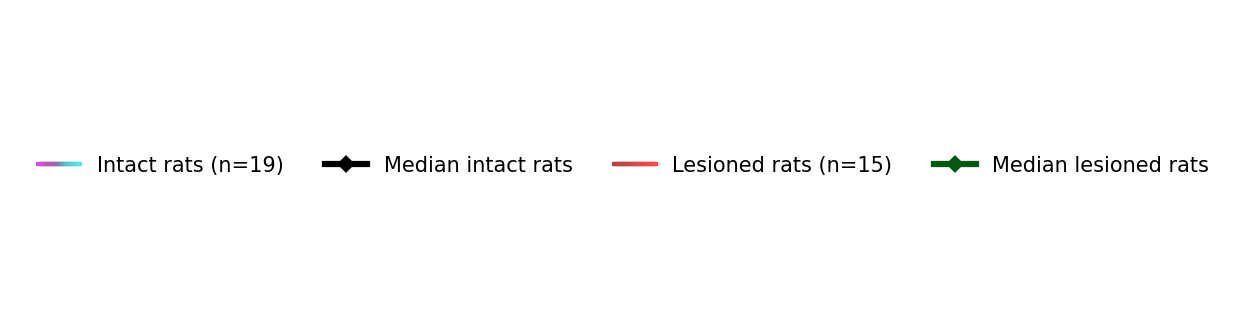

In [6]:
def dummy_legend(ax=None, intact_rats=intact_rats, VSlesioned_rats=VSlesioned_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    median_intact = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median intact rats', zorder=5)
    median_lesion = ax.plot([-100, -101], [-100, -101], color='xkcd:deep green', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median lesioned rats', zorder=5)
    
    patches = add_colored_lesion(ax=ax, do_return=True, group='VS')
    add_colored_intact(ax=ax, loc='center', bbox=(.5, .5), ncol=4,
                        handles=[median_intact, *patches, median_lesion],
                        labels=['Median intact rats', f'Lesioned rats (n={len(VSlesioned_rats)})', 'Median lesioned rats'], 
                        text=f'Intact rats (n={len(intact_rats)})')
    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

[0.9984 0.9913 0.9829 0.9418 0.9389 0.9971 0.991  0.973 ]
[0.0003 0.0002 0.0141 0.0136 0.0233 0.0026 0.0251 0.0116]
[0.0236 0.1151 0.2263 0.03   0.0827 0.012  0.0342 0.1703]
[0.4268 0.2036 0.6407 0.2987 0.5022 0.0373 0.2674 0.3624]
[0.9971 0.9931 0.9958 1.     1.     0.9969 0.9978 0.9996]
[0.6403 0.6396 0.2862 0.2218 0.107  0.1613 0.1811 0.5019]
[0.9961 1.     0.9938 0.9998 0.9997 0.9994 0.9995 0.9993]
[0.0016 0.0024 0.006  0.     0.0003 0.0005 0.     0.0014]
[0.6927 0.8625 0.9875 0.6227 0.9935 0.9732 0.9601 0.9912]
[0.8908 0.9879 0.964  0.9879 0.9965 0.9922 0.9949 0.9992]
[0.0059 0.3226 0.6049 0.0044 0.0015 0.0272 0.1091 0.0923]
[0.9624 0.9928 0.9964 1.     1.     0.9995 0.9994 1.    ]


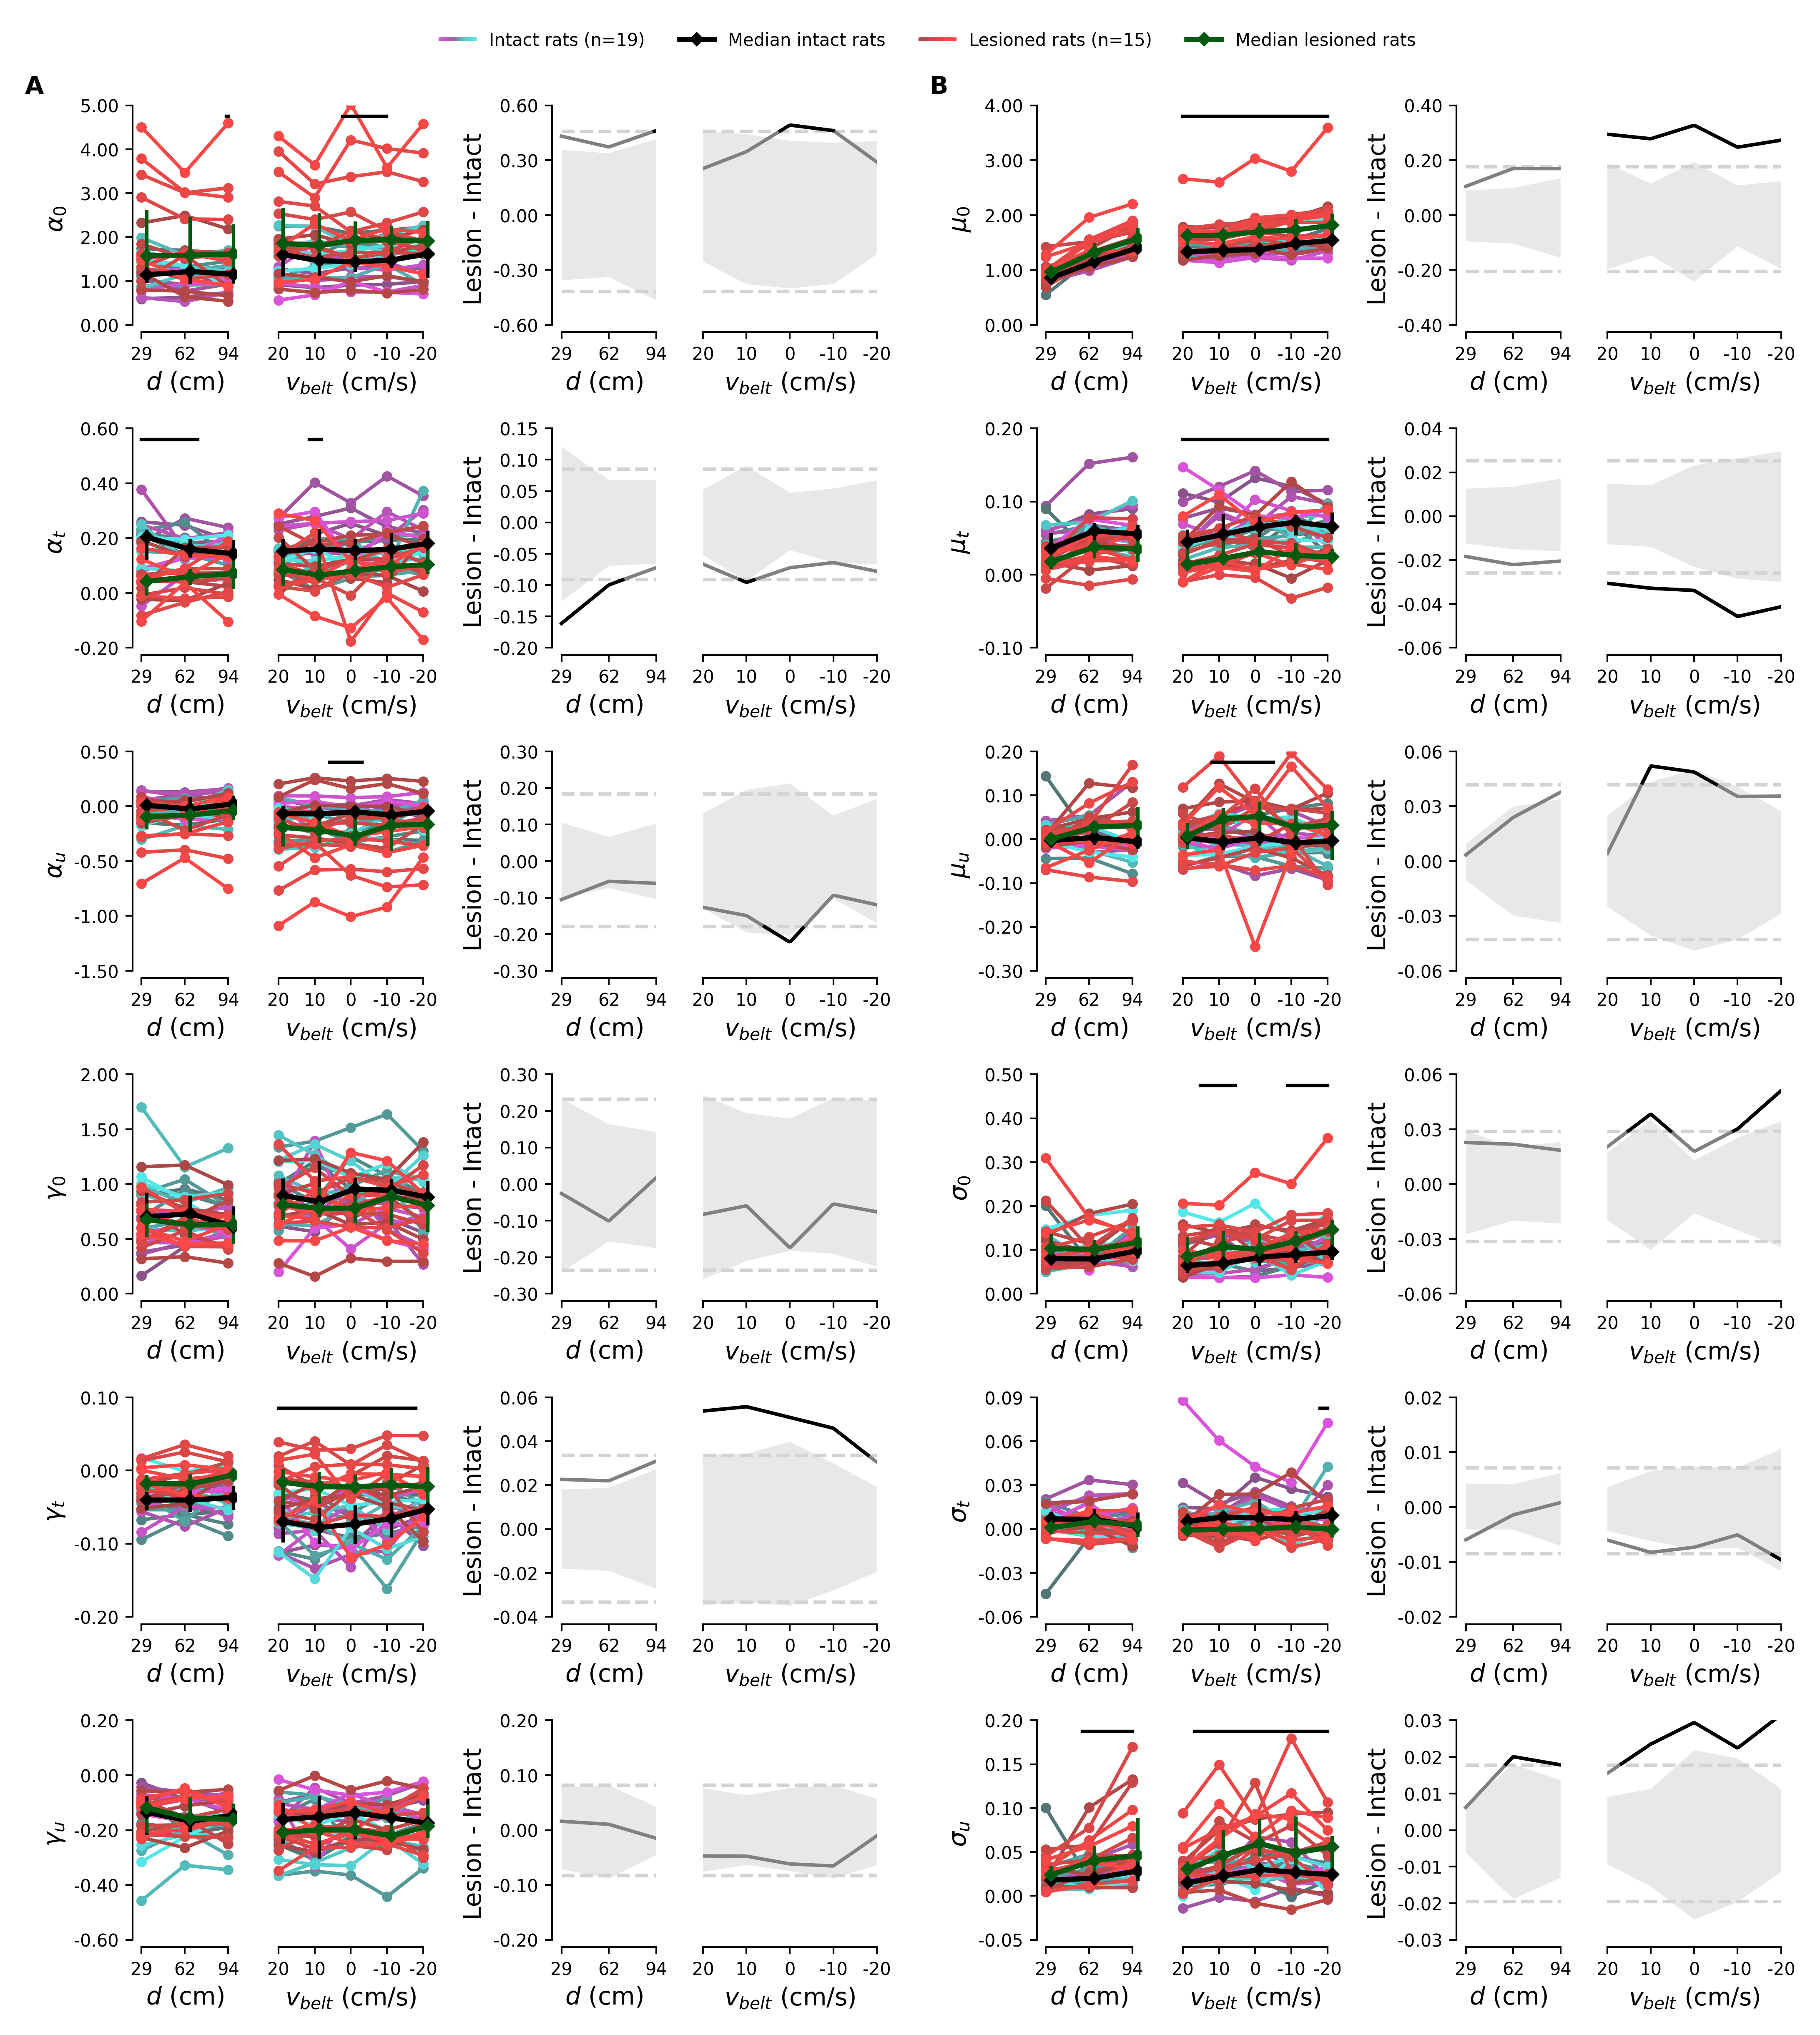

In [7]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(20)), dpi=600, constrained_layout=True, facecolor='w')

gs0 = fig.add_gridspec(7, 9 , height_ratios=[.05, 1, 1, 1, 1, 1, 1], width_ratios=[.75, 1.25, .75, 1.25, .05, .75, 1.25, .75, 1.25])

ax_alpha_0_d = fig.add_subplot(gs0[1, 0])
ax_alpha_0_vbelt = fig.add_subplot(gs0[1, 1])
ax_alpha_0_d_stats = fig.add_subplot(gs0[1, 2])
ax_alpha_0_vbelt_stats = fig.add_subplot(gs0[1, 3])
ax_alpha_t_d = fig.add_subplot(gs0[2, 0])
ax_alpha_t_vbelt = fig.add_subplot(gs0[2, 1])
ax_alpha_t_d_stats = fig.add_subplot(gs0[2, 2])
ax_alpha_t_vbelt_stats = fig.add_subplot(gs0[2, 3])
ax_alpha_u_d = fig.add_subplot(gs0[3, 0])
ax_alpha_u_vbelt = fig.add_subplot(gs0[3, 1])
ax_alpha_u_d_stats = fig.add_subplot(gs0[3, 2])
ax_alpha_u_vbelt_stats = fig.add_subplot(gs0[3, 3])

ax_gamma_0_d = fig.add_subplot(gs0[4, 0])
ax_gamma_0_vbelt = fig.add_subplot(gs0[4, 1])
ax_gamma_0_d_stats = fig.add_subplot(gs0[4, 2])
ax_gamma_0_vbelt_stats = fig.add_subplot(gs0[4, 3])
ax_gamma_t_d = fig.add_subplot(gs0[5, 0])
ax_gamma_t_vbelt = fig.add_subplot(gs0[5, 1])
ax_gamma_t_d_stats = fig.add_subplot(gs0[5, 2])
ax_gamma_t_vbelt_stats = fig.add_subplot(gs0[5, 3])
ax_gamma_u_d = fig.add_subplot(gs0[6, 0])
ax_gamma_u_vbelt = fig.add_subplot(gs0[6, 1])
ax_gamma_u_d_stats = fig.add_subplot(gs0[6, 2])
ax_gamma_u_vbelt_stats = fig.add_subplot(gs0[6, 3])


ax_mu_0_d = fig.add_subplot(gs0[1, 5])
ax_mu_0_vbelt = fig.add_subplot(gs0[1, 6])
ax_mu_0_d_stats = fig.add_subplot(gs0[1, 7])
ax_mu_0_vbelt_stats = fig.add_subplot(gs0[1, 8])
ax_mu_t_d = fig.add_subplot(gs0[2, 5])
ax_mu_t_vbelt = fig.add_subplot(gs0[2, 6])
ax_mu_t_d_stats = fig.add_subplot(gs0[2, 7])
ax_mu_t_vbelt_stats = fig.add_subplot(gs0[2, 8])
ax_mu_u_d = fig.add_subplot(gs0[3, 5])
ax_mu_u_vbelt = fig.add_subplot(gs0[3, 6])
ax_mu_u_d_stats = fig.add_subplot(gs0[3, 7])
ax_mu_u_vbelt_stats = fig.add_subplot(gs0[3, 8])

ax_sigma_0_d = fig.add_subplot(gs0[4, 5])
ax_sigma_0_vbelt = fig.add_subplot(gs0[4, 6])
ax_sigma_0_d_stats = fig.add_subplot(gs0[4, 7])
ax_sigma_0_vbelt_stats = fig.add_subplot(gs0[4, 8])
ax_sigma_t_d = fig.add_subplot(gs0[5, 5])
ax_sigma_t_vbelt = fig.add_subplot(gs0[5, 6])
ax_sigma_t_d_stats = fig.add_subplot(gs0[5, 7])
ax_sigma_t_vbelt_stats = fig.add_subplot(gs0[5, 8])
ax_sigma_u_d = fig.add_subplot(gs0[6, 5])
ax_sigma_u_vbelt = fig.add_subplot(gs0[6, 6])
ax_sigma_u_d_stats = fig.add_subplot(gs0[6, 7])
ax_sigma_u_vbelt_stats = fig.add_subplot(gs0[6, 8])


FigureS14AB(alpha_0, 'alpha_0', ax_d=ax_alpha_0_d, ax_stat_d=ax_alpha_0_d_stats, ax_vbelt=ax_alpha_0_vbelt, ax_stat_vbelt=ax_alpha_0_vbelt_stats)
FigureS14AB(alpha_t, 'alpha_t', ax_d=ax_alpha_t_d, ax_stat_d=ax_alpha_t_d_stats, ax_vbelt=ax_alpha_t_vbelt, ax_stat_vbelt=ax_alpha_t_vbelt_stats)
FigureS14AB(alpha_u, 'alpha_u', ax_d=ax_alpha_u_d, ax_stat_d=ax_alpha_u_d_stats, ax_vbelt=ax_alpha_u_vbelt, ax_stat_vbelt=ax_alpha_u_vbelt_stats)
FigureS14AB(gamma_0, 'gamma_0', ax_d=ax_gamma_0_d, ax_stat_d=ax_gamma_0_d_stats, ax_vbelt=ax_gamma_0_vbelt, ax_stat_vbelt=ax_gamma_0_vbelt_stats)
FigureS14AB(gamma_t, 'gamma_t', ax_d=ax_gamma_t_d, ax_stat_d=ax_gamma_t_d_stats, ax_vbelt=ax_gamma_t_vbelt, ax_stat_vbelt=ax_gamma_t_vbelt_stats)
FigureS14AB(gamma_u, 'gamma_u', ax_d=ax_gamma_u_d, ax_stat_d=ax_gamma_u_d_stats, ax_vbelt=ax_gamma_u_vbelt, ax_stat_vbelt=ax_gamma_u_vbelt_stats)

FigureS14AB(mu_0, 'mu_0', ax_d=ax_mu_0_d, ax_stat_d=ax_mu_0_d_stats, ax_vbelt=ax_mu_0_vbelt, ax_stat_vbelt=ax_mu_0_vbelt_stats)
FigureS14AB(mu_t, 'mu_t', ax_d=ax_mu_t_d, ax_stat_d=ax_mu_t_d_stats, ax_vbelt=ax_mu_t_vbelt, ax_stat_vbelt=ax_mu_t_vbelt_stats)
FigureS14AB(mu_u, 'mu_u', ax_d=ax_mu_u_d, ax_stat_d=ax_mu_u_d_stats, ax_vbelt=ax_mu_u_vbelt, ax_stat_vbelt=ax_mu_u_vbelt_stats)
FigureS14AB(sigma_0, 'sigma_0', ax_d=ax_sigma_0_d, ax_stat_d=ax_sigma_0_d_stats, ax_vbelt=ax_sigma_0_vbelt, ax_stat_vbelt=ax_sigma_0_vbelt_stats)
FigureS14AB(sigma_t, 'sigma_t', ax_d=ax_sigma_t_d, ax_stat_d=ax_sigma_t_d_stats, ax_vbelt=ax_sigma_t_vbelt, ax_stat_vbelt=ax_sigma_t_vbelt_stats)
FigureS14AB(sigma_u, 'sigma_u', ax_d=ax_sigma_u_d, ax_stat_d=ax_sigma_u_d_stats, ax_vbelt=ax_sigma_u_vbelt, ax_stat_vbelt=ax_sigma_u_vbelt_stats)

axes = fig.get_axes()
for ax in axes:
    ax.yaxis.set_major_formatter('{x:>5.2f}')

legend = fig.add_axes([.5, 1., .01, .01])
dummy_legend(ax=legend)

axs = [ax_alpha_0_d, ax_mu_0_d]
letters = ['A', 'B']
add_all_letters(axs, letters)

plt.savefig("./Figures_paper/Figure_S14VS.pdf", facecolor='w', 
            edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_S14VS.svg", facecolor='w', 
            edgecolor='none', bbox_inches='tight', format="svg", dpi=600)